In [1]:
from POSEIDON.core import create_star
from POSEIDON.constants import R_Sun

#***** Define stellar properties *****#

R_s = 0.87*R_Sun      # Stellar radius (m)
T_s = 5079.0          # Stellar effective temperature (K)
Met_s = -0.04         # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 4.56        # Stellar log surface gravity (log10(cm/s^2) by convention)

# Create the stellar object
star = create_star(R_s, T_s, log_g_s, Met_s)

/home/ers1n25/miniconda3/envs/poseidon/lib/python3.11/site-packages/pysynphot/__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/home/ers1n25/miniconda3/envs/poseidon/lib/python3.11/site-packages/pysynphot/locations.py:46: UserWarning: PYSYN_CDBS is undefined; functionality will be SEVERELY crippled.
  warnings.warn("PYSYN_CDBS is undefined; functionality will be SEVERELY "
/home/ers1n25/miniconda3/envs/poseidon/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [2]:
from POSEIDON.core import create_planet
from POSEIDON.constants import R_J, M_J

#***** Define planet properties *****#

planet_name = 'HAT-P-26b'  # Planet name used for plots, output files etc.

R_p = 0.63*R_J      # Planetary radius (m)
M_p = 0.07*M_J      # Mass of planet (kg)
g_p = 4.3712        # Gravitational field of planet (m/s^2)
T_eq = 1043.8       # Equilibrium temperature (K)

# Create the planet object
planet = create_planet(planet_name, R_p, mass = M_p, gravity = g_p, T_eq = T_eq)

In [3]:
from POSEIDON.core import define_model

#***** Define model *****#

model_name = 'Simple_model'  # Model name used for plots, output files etc.

bulk_species = ['H2', 'He']      # H2 + He comprises the bulk atmosphere
param_species = ['H2O', 'CH4']   # The trace gases are H2O and CH4

# Create the model object
model = define_model(model_name, bulk_species, param_species,
                     PT_profile = 'isotherm', cloud_model = 'cloud-free')

In [4]:
# Check the free parameters defining this model
print("Free parameters: " + str(model['param_names']))

Free parameters: ['R_p_ref' 'T' 'log_H2O' 'log_CH4']


In [5]:
print(model['PT_param_names'])
print(model['X_param_names'])

['T']
['log_H2O' 'log_CH4']


In [6]:
from POSEIDON.core import make_atmosphere
import numpy as np

# Specify the pressure grid of the atmosphere
P_min = 1.0e-7    # 0.1 ubar
P_max = 100       # 100 bar
N_layers = 100    # 100 layers

# We'll space the layers uniformly in log-pressure
P = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)

# Specify the reference pressure and radius
P_ref = 10.0   # Reference pressure (bar)
R_p_ref = R_p  # Radius at reference pressure

# Provide a specific set of model parameters for the atmosphere
PT_params = np.array([1000])              # T (K)
log_X_params = np.array([-3.3, -5.0])     # log(H2O), log(CH4)

# Generate the atmosphere
atmosphere = make_atmosphere(planet, model, P, P_ref, R_p_ref,
                             PT_params, log_X_params)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


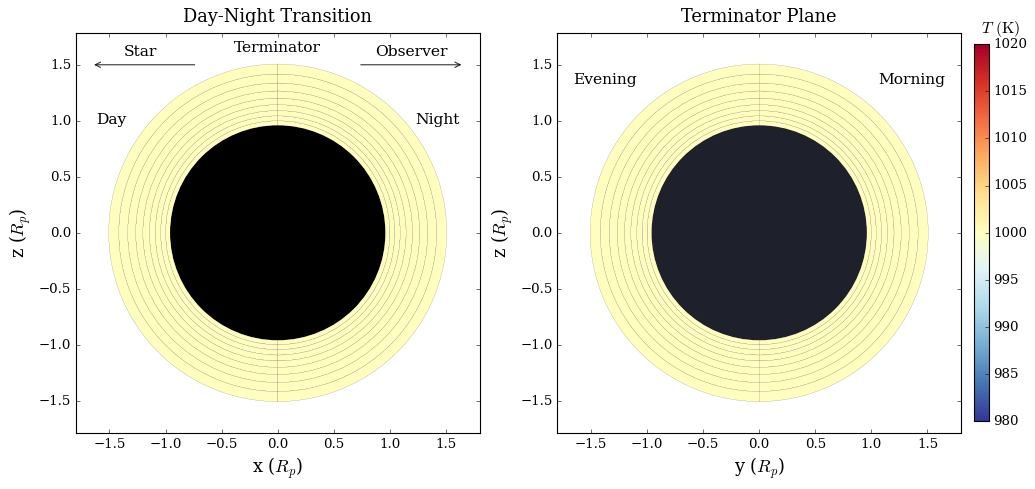

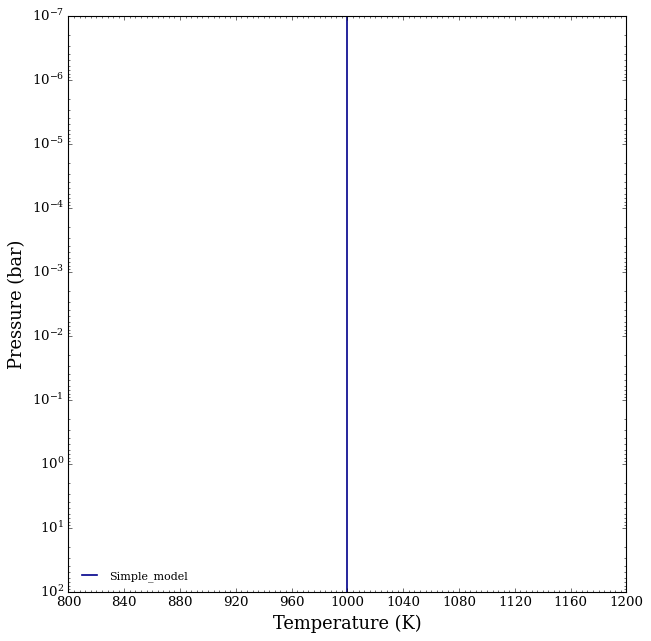

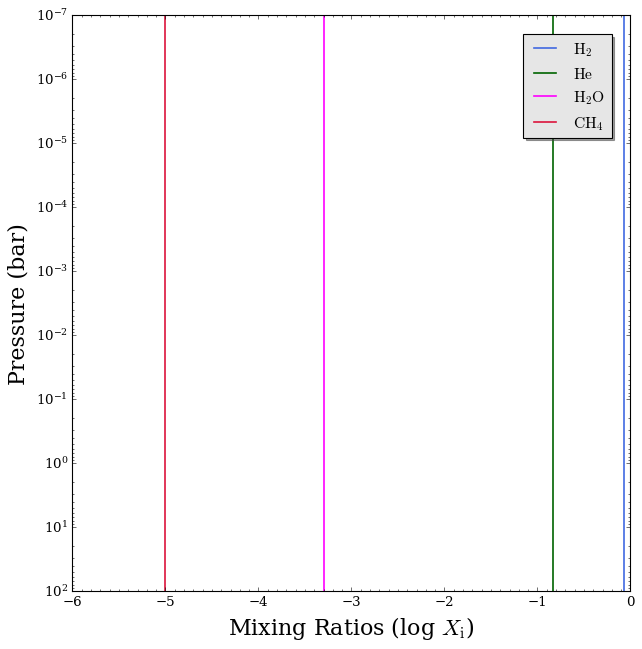

In [7]:
from POSEIDON.visuals import plot_geometry, plot_PT, plot_chem

# Produce plots of atmospheric properties
fig_geom = plot_geometry(planet, star, model, atmosphere)
fig_PT = plot_PT(planet, model, atmosphere)
fig_chem = plot_chem(planet, model, atmosphere)

In [10]:
import os
os.environ["POSEIDON_input_data"] = "/home/ers1n25/POSEIDON/inputs"

In [11]:
from POSEIDON.core import read_opacities, wl_grid_constant_R

#***** Wavelength grid *****#

wl_min = 0.6      # Minimum wavelength (um)
wl_max = 5.2      # Maximum wavelength (um)
R = 10000         # Spectral resolution of grid

wl = wl_grid_constant_R(wl_min, wl_max, R)

#***** Read opacity data *****#

opacity_treatment = 'opacity_sampling'

# First, specify limits of the fine temperature and pressure grids for the
# pre-interpolation of cross sections. These fine grids should cover a
# wide range of possible temperatures and pressures for the model atmosphere.

# Define fine temperature grid (K)
T_fine_min = 400     # 400 K lower limit suffices for a typical hot Jupiter
T_fine_max = 2000    # 2000 K upper limit suffices for a typical hot Jupiter
T_fine_step = 10     # 10 K steps are a good tradeoff between accuracy and RAM

T_fine = np.arange(T_fine_min, (T_fine_max + T_fine_step), T_fine_step)

# Define fine pressure grid (log10(P/bar))
log_P_fine_min = -6.0   # 1 ubar is the lowest pressure in the opacity database
log_P_fine_max = 2.0    # 100 bar is the highest pressure in the opacity database
log_P_fine_step = 0.2   # 0.2 dex steps are a good tradeoff between accuracy and RAM

log_P_fine = np.arange(log_P_fine_min, (log_P_fine_max + log_P_fine_step),
                       log_P_fine_step)

# Now we can pre-interpolate the sampled opacities (may take up to a minute)
opac = read_opacities(model, wl, opacity_treatment, T_fine, log_P_fine)

Reading in cross sections in opacity sampling mode...
H2-H2 done
H2-He done
H2-CH4 done
H2O done
CH4 done
Opacity pre-interpolation complete.


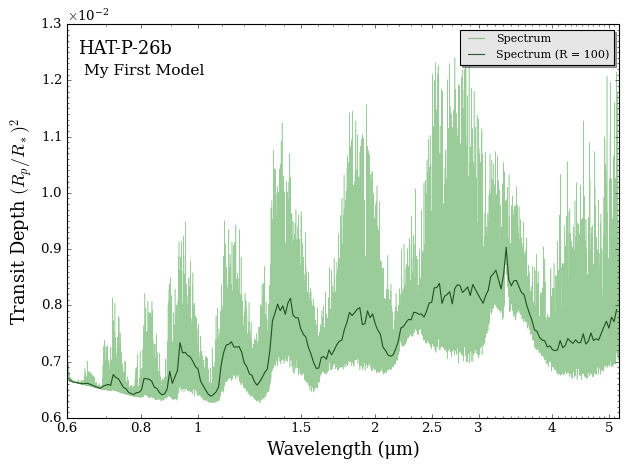

In [12]:
from POSEIDON.core import compute_spectrum
from POSEIDON.visuals import plot_spectra
from POSEIDON.utility import plot_collection

# Generate our first transmission spectrum
spectrum = compute_spectrum(planet, star, model, atmosphere, opac, wl,
                            spectrum_type = 'transmission')

# Add the spectrum we want to plot to an empty spectra plot collection
spectra = plot_collection(spectrum, wl, collection = [])

# Produce figure and save to file
fig = plot_spectra(spectra, planet, R_to_bin = 100, plt_label = 'My First Model')

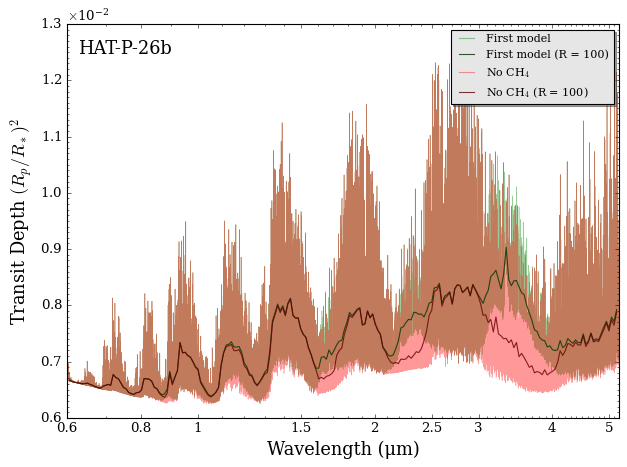

In [13]:
# Define new mixing ratio array with a low CH4 abundance
log_X_params_no_CH4 = np.array([[-3.3, -50.0]])  # log(H2O), log(CH4)

# Create a new atmosphere without CH4
atmosphere_no_CH4 = make_atmosphere(planet, model, P, P_ref, R_p_ref,
                                    PT_params, log_X_params_no_CH4)

# Generate the new transmission spectrum
spectrum_no_CH4 = compute_spectrum(planet, star, model, atmosphere_no_CH4,
                                   opac, wl, spectrum_type = 'transmission')

# Add the spectrum we want to plot to our existing plot collection
spectra = plot_collection(spectrum_no_CH4, wl, collection = spectra)

# Produce figure
fig_spec = plot_spectra(spectra, planet, R_to_bin = 100,
                        spectra_labels = ['First model', 'No CH$_4$'])

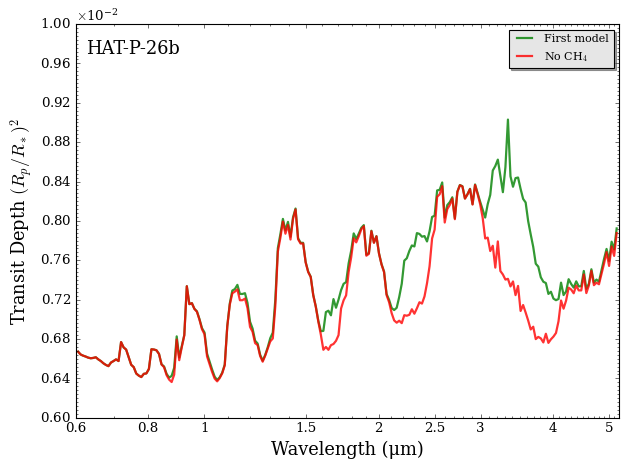

In [14]:
# Produce figure
fig_spec = plot_spectra(spectra, planet, R_to_bin = 100,
                        plot_full_res = False,
                        spectra_labels = ['First model', 'No CH$_4$'],
                        y_min = 0.6e-2, y_max = 1.0e-2)

In [15]:
from POSEIDON.core import wl_grid_line_by_line

#***** Wavelength grid *****#

wl_min = 0.6      # Minimum wavelength (um)
wl_max = 5.2      # Maximum wavelength (um)

wl_high_res = wl_grid_line_by_line(wl_min, wl_max)

#***** Read opacity data *****#

opacity_treatment = 'line_by_line'

# Prepare high-resolution opacity data
opac_high_res = read_opacities(model, wl_high_res, opacity_treatment)

Reading in cross sections in line-by-line mode...
H2-H2 done
H2-He done
H2-CH4 done
H2O done
CH4 done
Finished producing extinction coefficients


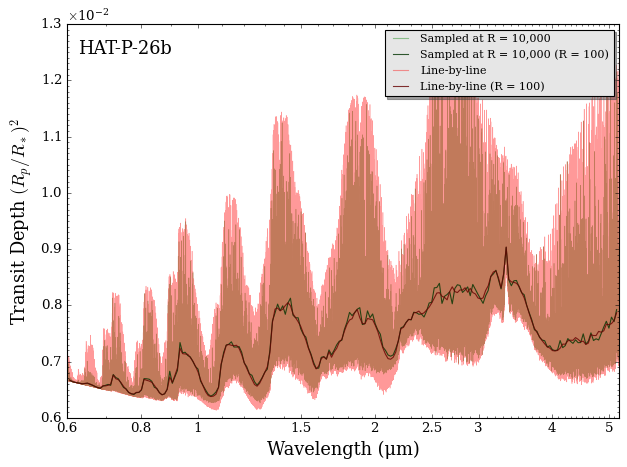

In [16]:
# Generate the high-resolution spectrum
spectrum_high_res = compute_spectrum(planet, star, model, atmosphere,
                                     opac_high_res, wl_high_res,
                                     spectrum_type = 'transmission')

# Add both the low-res and high-res spectra to a new plot collection
spectra = plot_collection(spectrum, wl, collection = [])
spectra = plot_collection(spectrum_high_res, wl_high_res, collection = spectra)

# Produce figure
fig = plot_spectra(spectra, planet, model, R_to_bin = 100,
                   spectra_labels = ['Sampled at R = 10,000', 'Line-by-line'])